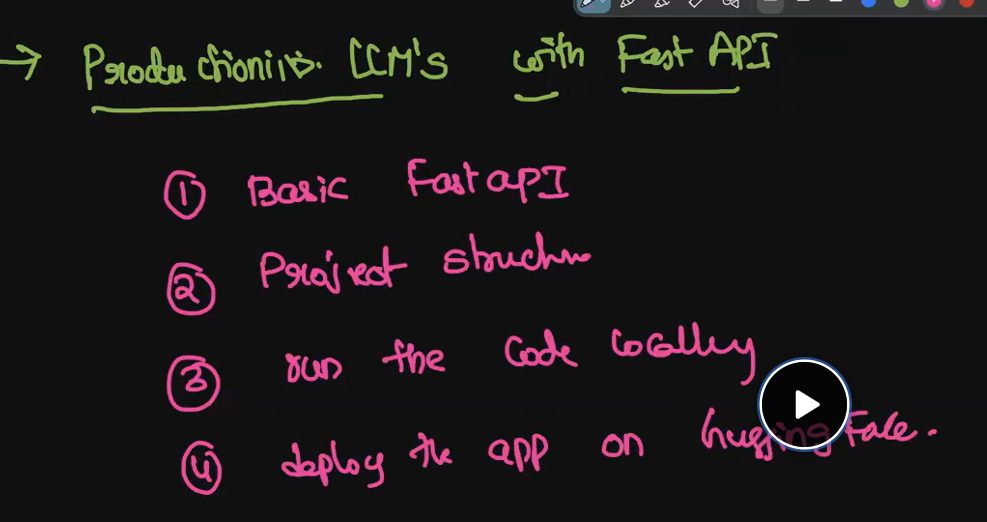

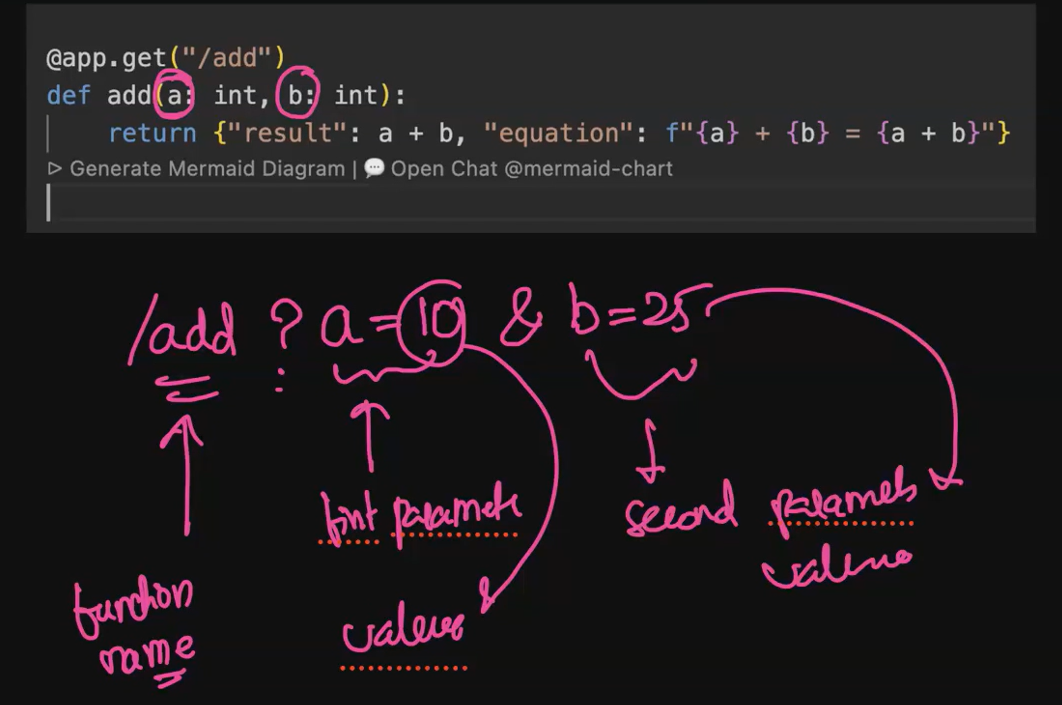

#### FastAPU is like SpringBoot for Python. It is a framework to build APIs. It is built on top of Starlette and Pydantic. It is very fast and easy to use. It is used to build APIs for Machine Learning models,deploy Machine Learning models as APIs, build RESTful APIs, build GraphQL APIs, WebSocket APIs, Background Tasks, build Dependency Injection, Security, CORS, Middleware, Exception Handling, Logging, Testing, Documentation, OpenAPI, JSON Schema.

In [39]:
%pip install fastapi

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
%pip install uvicorn

^C
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
%pip install pydantic

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Imports

In [52]:
import os
from dotenv import load_dotenv
from openai import OpenAI
import logging
from pydantic import BaseModel
import chromadb
from IPython.display import Markdown,display
from fastapi import FastAPI
import uuid

### API Key loading from .env file

In [ ]:
load_dotenv()
groqAPIKey = os.getenv("GroqAPIKey")

client = OpenAI(api_key=groqAPIKey,base_url="https://api.groq.com/openai/v1")

chromaClient = chromadb.Client()

### Initializing the Logger

In [ ]:
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(message)s")
logger=logging.getLogger(__name__)

### Sample usage of Pydantic models
Pydantic models are for request and response validation. Pydantic is a data validation and settings management library for Python. It uses Python type annotations to validate data. It is used to validate request and response data in FastAPI. It is also used to define settings for the application.

In [ ]:
class apirequest(BaseModel):
    a: int
    b: int

def add(input:apirequest):
    print(input.a + input.b)    

In [ ]:
add(apirequest(a=10,b=89))

99


In [ ]:
add(apirequest(a="apple",b=89))

ValidationError: 1 validation error for apirequest
a
  Input should be a valid integer, unable to parse string as an integer [type=int_parsing, input_value='apple', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/int_parsing

In [ ]:
#Pydantic will auto coerse the eligible strings to int. If the string is not eligible for coercion, it will throw an validation error.
add(apirequest(a=20.3,b=89))

ValidationError: 1 validation error for apirequest
a
  Input should be a valid integer, got a number with a fractional part [type=int_from_float, input_value=20.3, input_type=float]
    For further information visit https://errors.pydantic.dev/2.12/v/int_from_float

In [ ]:
add(apirequest(a="20",b="89"))

109


In [ ]:
add(apirequest(a="20",b=89))

109


### Load and Index Data

In [ ]:
def loadAndIndexDocs(verbose):
    docFolder = os.path.join(os.path.dirname("__file__"),"Data Documents")
    if verbose:
        print(f"Documents are in '{docFolder}' folder.")

    try:
        chromaClient.delete_collection("NovaTechData")
    except:
        pass

    collection=chromaClient.create_collection("NovaTechData")

    allChunks=[]
    allChunkIds=[]
    allMetadata=[]
    chunkID=1

    for fileName in os.listdir(docFolder):
        
        if not fileName.endswith("txt"):
            continue

        filePath = os.path.join(docFolder,fileName)
        if verbose:
            print(filePath)
        with open(filePath,"r") as cntxtMngr:
            text = cntxtMngr.read()
            if verbose:
                print(text[:10])

        text = text.replace("=",'')
        words = text.split()
        chunkSize=100
        overlap=20

        for i in range(0,len(words),chunkSize-overlap):
            chunk = ' '.join(words[i:i+chunkSize])
            allChunks.append(chunk)
            allChunkIds.append(f"Chunk_{chunkID}")
            allMetadata.append({"source":fileName})
            chunkID+=1

        if verbose:
            print(f"allChunkIds: \n{allChunkIds}")    
            print(f"allChunks: \n{allChunks}")


    collection.add(documents=allChunks,ids=allChunkIds,metadatas=allMetadata)
    logger.info(f"Indexed {chunkID} from {docFolder}")
    return collection



        #print(words)


In [ ]:
vectorCollc = loadAndIndexDocs(False)

2026-07-21 23:25:04,053 | Indexed 63 from Data Documents


### Defining the RAG function

In [53]:
def askRAG(userQry,topK=3):
    usrQryResult = vectorCollc.query(query_texts=[userQry],n_results=topK)
    usrQryChunks = usrQryResult["documents"][0]

    sources = [m["source"] for m in usrQryResult["metadatas"][0]]

    context = "\n\n".join(usrQryChunks)

    message = [{
        "role":"system",
        "content":"You are an useful assistent of NovaTech solutions. Answer the question only from the provided information, with the source of the information. If the enough inormation to answer the user query is not available, then reply 'I do not have enough information to answer this question'."
    },
    {
        "role":"user",
        "content": f"Context: \n{context}\n\nmetadata: \n{sources}\n\nUser Question:\n{userQry}"
    }]

    llmResult = client.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=message
    )

    logger.info(f"Response received from LLM: {llmResult}")

    return llmResult.choices[0].message.content

   


In [49]:
answerLLM = askRAG("What is the WFH policy?",3)
#print(f"Answer for LLM: \n {answerLLM}")
display(Markdown(answerLLM))

2026-07-21 23:49:36,337 | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-07-21 23:49:36,340 | Response received from LLM: ChatCompletion(id='chatcmpl-39325c06-823e-464d-a51b-da283a716488', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='**Work‑From‑Home (WFH) Policy**\n\n- **Eligibility**\n  - Employees in their probation period (first\u202f6\u202fmonths) are not allowed to work from home unless they receive explicit approval from both their manager and HR.  \n  - After the probation period, employees may work from home up to **2\u202fdays per week**. The preferred days are **Wednesday and Friday**, though teams can adjust the schedule based on project needs.  \n  - Some roles are hired as **fully‑remote**; this is decided at the time of hiring and recorded in the offer letter.  \n\n- **Core Hours & Availability**\n  - On WFH days employees must be available during core working hours **10:00

**Work‑From‑Home (WFH) Policy**

- **Eligibility**
  - Employees in their probation period (first 6 months) are not allowed to work from home unless they receive explicit approval from both their manager and HR.  
  - After the probation period, employees may work from home up to **2 days per week**. The preferred days are **Wednesday and Friday**, though teams can adjust the schedule based on project needs.  
  - Some roles are hired as **fully‑remote**; this is decided at the time of hiring and recorded in the offer letter.  

- **Core Hours & Availability**
  - On WFH days employees must be available during core working hours **10:00 AM – 6:00 PM IST**.  
  - All meetings must be attended via video call with the camera turned on.  
  - Employees must respond to messages within **30 minutes** during core hours.  
  - Any planned unavailability on a WFH day must be communicated in advance.  

- **Productivity Expectation**
  - Employees are required to maintain the same productivity levels as when working in the office.  

- **Additional Notes**
  - WFH is not permitted during probation unless an exceptional circumstance is approved by the manager and HR.  

**Source:** *company_hr_policy.txt* (sections on “WFH Expectations” and “Work From Home (WFH) arrangements”).

### Configuring FastAPI